<a href="https://colab.research.google.com/github/jalipe-cloud/aprendizaje-maquina/blob/main/caso2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sistema de Reconocimiento de Rostros con Eigenfaces (PCA)

**Dataset:** Olivetti Faces (scikit-learn)

**Objetivo:** Construir un sistema de reconocimiento facial basado en la técnica clásica de **Eigenfaces**, usando **PCA** (Análisis de Componentes Principales) para reducir la dimensionalidad de las imágenes y un clasificador simple (no basado en redes neuronales) para identificar a la persona.

**Contenido:**
1. Carga y exploración del dataset
2. Rostro promedio
3. Cálculo de Eigenfaces (PCA)
4. Reconstrucción de rostros
5. Sistema de reconocimiento (clasificador de vecino más cercano)
6. Evaluación y análisis de resultados
7. Efecto del número de componentes principales
8. Conclusiones

In [1]:
# Importación de librerías
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## 1. Carga y exploración del dataset

El dataset **Olivetti Faces** contiene 400 imágenes en escala de grises (64x64 píxeles) de 40 personas distintas (10 fotos por persona), tomadas en diferentes momentos, con variaciones de iluminación, expresión facial (ojos abiertos/cerrados, sonriendo/serio) y detalles (con/sin lentes).

In [2]:
# Carga del dataset
# Nota: si aparece un error 'HTTP Error 403: Forbidden', el servidor de
# figshare está rechazando la petición por no tener un User-Agent de
# navegador. Registramos un opener con User-Agent antes de descargar.
import urllib.request
opener = urllib.request.build_opener()
opener.addheaders = [('User-Agent', 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)')]
urllib.request.install_opener(opener)

import time
max_intentos = 3
faces = None
for intento in range(1, max_intentos + 1):
    try:
        faces = fetch_olivetti_faces(shuffle=True, random_state=42)
        break
    except Exception as e:
        print(f"Intento {intento} fallido: {e}")
        if intento < max_intentos:
            time.sleep(3)

if faces is None:
    raise RuntimeError(
        "No se pudo descargar el dataset Olivetti Faces tras varios intentos. "
        "Reinicia el entorno de ejecución (Entorno de ejecución > Reiniciar entorno "
        "de ejecución) y vuelve a correr la celda."
    )

X = faces.data          # (400, 4096) -> imágenes aplanadas
y = faces.target        # (400,)      -> identidad de la persona (0 a 39)
images = faces.images   # (400, 64, 64) -> imágenes en su forma original

n_samples, n_features = X.shape
n_classes = len(np.unique(y))
h, w = images.shape[1], images.shape[2]

print(f"Número de muestras: {n_samples}")
print(f"Número de características (píxeles) por imagen: {n_features}")
print(f"Dimensiones de cada imagen: {h}x{w}")
print(f"Número de personas (clases): {n_classes}")
print(f"Fotos por persona: {n_samples // n_classes}")

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Número de muestras: 400
Número de características (píxeles) por imagen: 4096
Dimensiones de cada imagen: 64x64
Número de personas (clases): 40
Fotos por persona: 10


## 2. Visualización de muestras del dataset

In [ ]:
def plot_gallery(images, titles, h, w, n_row=3, n_col=6, cmap='gray'):
    plt.figure(figsize=(1.6 * n_col, 1.8 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape(h, w), cmap=cmap)
        plt.title(titles[i], size=10)
        plt.xticks(())
        plt.yticks(())

# Mostrar algunas caras de ejemplo (varias personas distintas)
titles = [f"Persona {y[i]}" for i in range(18)]
plot_gallery(X, titles, h, w)
plt.suptitle("Ejemplos del dataset Olivetti Faces", y=1.02)
plt.show()

# Mostrar las 10 fotos de una misma persona (variación intra-clase)
idx_persona0 = np.where(y == y[0])[0]
plot_gallery(X[idx_persona0], [f"Foto {i+1}" for i in range(10)], h, w, n_row=2, n_col=5)
plt.suptitle(f"Todas las fotos de la persona {y[0]} (variación de expresión/iluminación)", y=1.05)
plt.show()

## 3. División en entrenamiento y prueba

Usamos `stratify=y` para asegurar que cada persona quede representada proporcionalmente tanto en el conjunto de entrenamiento como en el de prueba.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Imágenes de entrenamiento: {X_train.shape[0]}")
print(f"Imágenes de prueba: {X_test.shape[0]}")

Imágenes de entrenamiento: 300
Imágenes de prueba: 100


## 4. Rostro promedio (Mean Face)

El primer paso conceptual de la técnica de Eigenfaces es calcular el rostro promedio del conjunto de entrenamiento, ya que PCA centra los datos restando esta media antes de calcular las componentes principales.

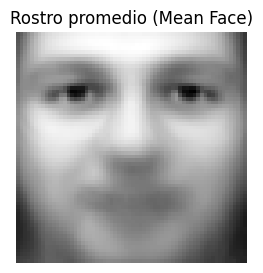

In [4]:
mean_face = X_train.mean(axis=0)

plt.figure(figsize=(3, 3))
plt.imshow(mean_face.reshape(h, w), cmap='gray')
plt.title("Rostro promedio (Mean Face)")
plt.axis('off')
plt.show()

## 5. Cálculo de Eigenfaces (PCA)

Aplicamos PCA sobre las imágenes de entrenamiento. Cada componente principal, al ser un vector de 4096 dimensiones (igual que una imagen), puede visualizarse como una "cara" — de ahí el nombre **Eigenface**. Estas eigenfaces representan las direcciones de mayor variación entre los rostros del dataset.

Primero analizamos cuánta varianza explica cada número de componentes, para elegir un valor razonable.

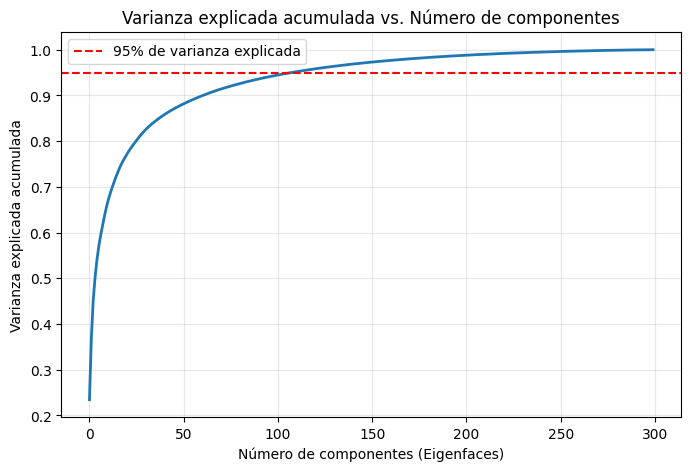

Componentes necesarias para explicar el 95% de la varianza: 109


In [5]:
# PCA con todas las componentes posibles para analizar varianza explicada
pca_full = PCA(whiten=True, random_state=42)
pca_full.fit(X_train)

explained_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(explained_var, linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% de varianza explicada')
plt.xlabel('Número de componentes (Eigenfaces)')
plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada acumulada vs. Número de componentes')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

n_components_95 = np.argmax(explained_var >= 0.95) + 1
print(f"Componentes necesarias para explicar el 95% de la varianza: {n_components_95}")

In [6]:
# Elegimos un número de componentes (eigenfaces) para el sistema
N_COMPONENTS = 100  # valor razonable: reduce 4096 dimensiones a 100, conservando la mayor parte de la varianza

pca = PCA(n_components=N_COMPONENTS, whiten=True, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Varianza explicada con {N_COMPONENTS} componentes: {pca.explained_variance_ratio_.sum():.4f}")
print(f"Dimensión original: {X_train.shape[1]} -> Dimensión reducida: {X_train_pca.shape[1]}")

Varianza explicada con 100 componentes: 0.9437
Dimensión original: 4096 -> Dimensión reducida: 100


### 5.1 Visualización de las Eigenfaces principales

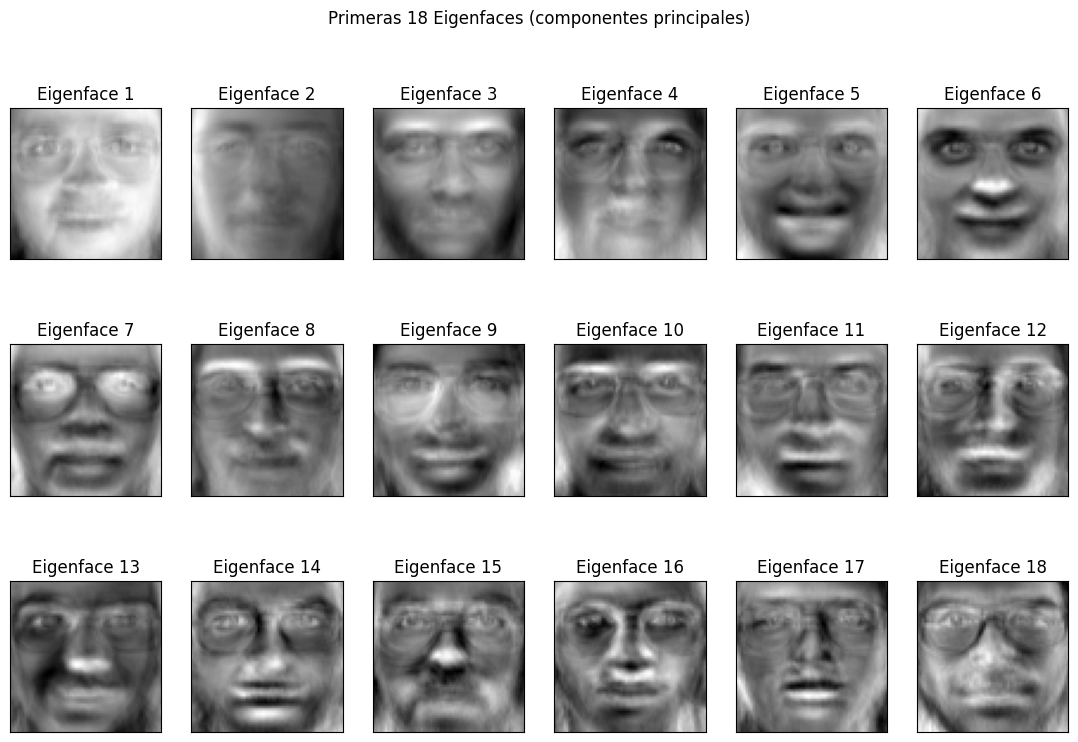

Interpretación:
- Las primeras eigenfaces capturan patrones globales de iluminación y forma general del rostro.
- Las eigenfaces posteriores capturan detalles más finos (ojos, nariz, boca, contornos).


In [12]:
import matplotlib.pyplot as plt

# 1. Definición de la función plot_gallery
def plot_gallery(images, titles, h, w, n_row=3, n_col=6):
    """Función auxiliar para dibujar una galería de retratos"""
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())

# 2. Tu código corregido (se ejecuta después de definir la función)
eigenfaces = pca.components_.reshape((N_COMPONENTS, h, w))
eigenface_titles = [f"Eigenface {i+1}" for i in range(18)]

# Ahora ya puedes llamar a la función sin errores
plot_gallery(eigenfaces, eigenface_titles, h, w)
plt.suptitle("Primeras 18 Eigenfaces (componentes principales)", y=1.02)
plt.show()

print("Interpretación:")
print("- Las primeras eigenfaces capturan patrones globales de iluminación y forma general del rostro.")
print("- Las eigenfaces posteriores capturan detalles más finos (ojos, nariz, boca, contornos).")


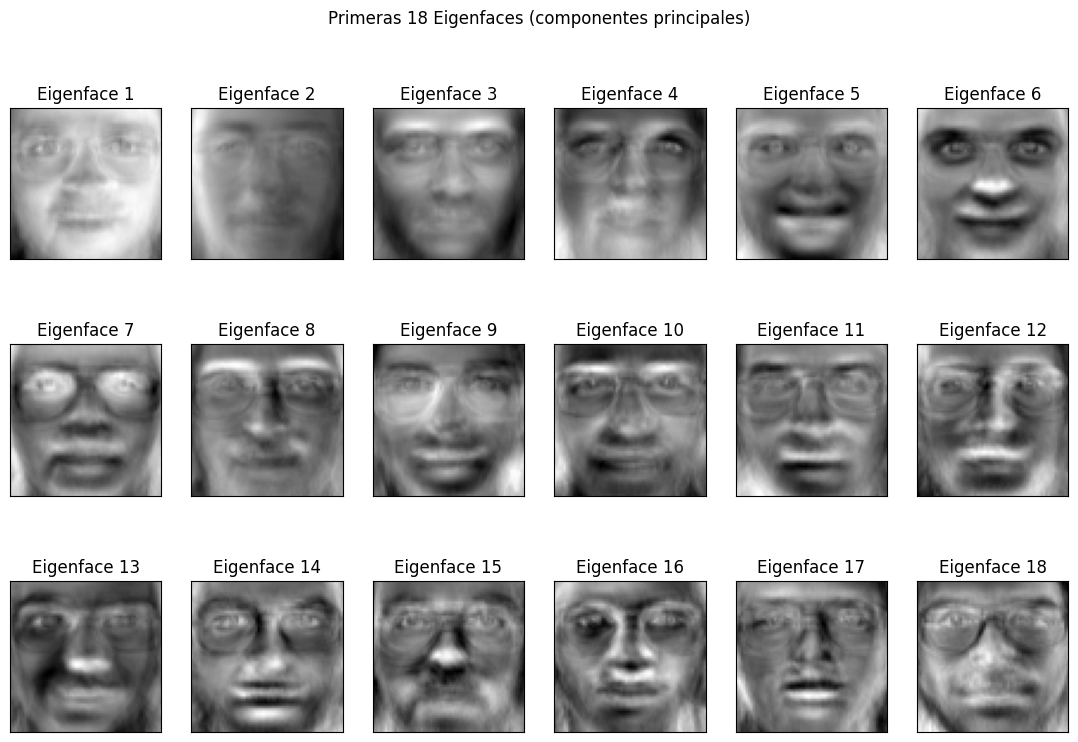

Interpretación:
- Las primeras eigenfaces capturan patrones globales de iluminación y forma general del rostro.
- Las eigenfaces posteriores capturan detalles más finos (ojos, nariz, boca, contornos).


In [13]:
# 1. Corrección del reshape y eliminación de 'let'
eigenfaces = pca.components_.reshape((N_COMPONENTS, h, w))

# 2. Corrección de la f-string (falta la comilla de apertura)
eigenface_titles = [f"Eigenface {i+1}" for i in range(18)]

# 3. Dibujo de la galería y el título principal
plot_gallery(eigenfaces, eigenface_titles, h, w)
plt.suptitle("Primeras 18 Eigenfaces (componentes principales)", y=1.02)
plt.show()

# 4. Corrección de los textos del print (faltaban comillas)
print("Interpretación:")
print("- Las primeras eigenfaces capturan patrones globales de iluminación y forma general del rostro.")
print("- Las eigenfaces posteriores capturan detalles más finos (ojos, nariz, boca, contornos).")


## 6. Reconstrucción de rostros

Podemos reconstruir una imagen a partir de sus proyecciones en el espacio de eigenfaces. Cuantas más componentes usemos, mejor será la reconstrucción, pero un número menor sigue capturando la esencia del rostro (esto es justo lo que hace útil a PCA para compresión y reconocimiento).

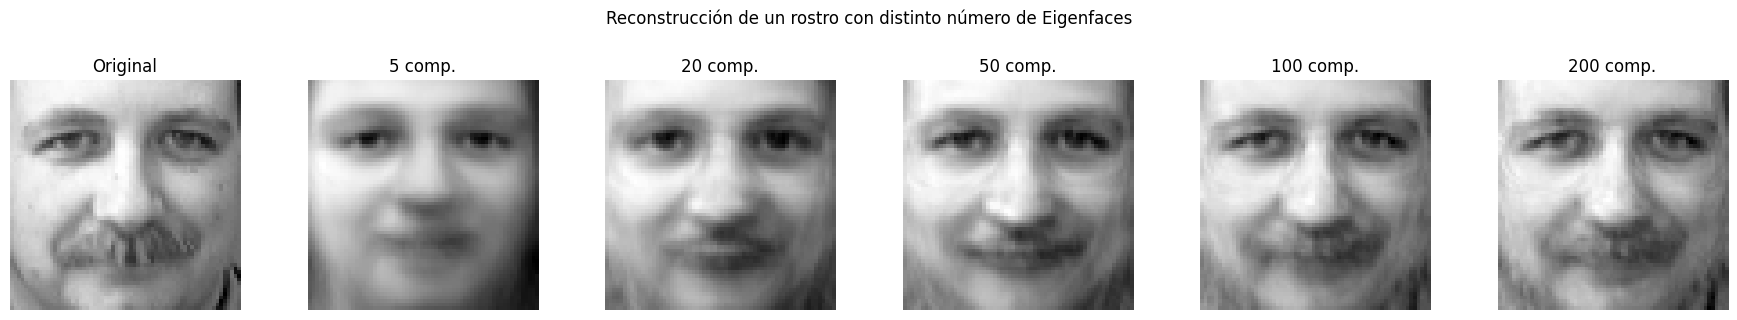

In [14]:
componentes_a_probar = [5, 20, 50, 100, 200]
idx_ejemplo = 0  # imagen de prueba a reconstruir

fig, axes = plt.subplots(1, len(componentes_a_probar) + 1, figsize=(3 * (len(componentes_a_probar) + 1), 3))

axes[0].imshow(X_test[idx_ejemplo].reshape(h, w), cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

for i, n_comp in enumerate(componentes_a_probar):
    pca_temp = PCA(n_components=n_comp, whiten=True, random_state=42)
    pca_temp.fit(X_train)
    proyeccion = pca_temp.transform(X_test[idx_ejemplo].reshape(1, -1))
    reconstruccion = pca_temp.inverse_transform(proyeccion)

    axes[i + 1].imshow(reconstruccion.reshape(h, w), cmap='gray')
    axes[i + 1].set_title(f"{n_comp} comp.")
    axes[i + 1].axis('off')

plt.suptitle("Reconstrucción de un rostro con distinto número de Eigenfaces", y=1.05)
plt.tight_layout()
plt.show()

## 7. Sistema de reconocimiento facial

El enfoque clásico de Eigenfaces (Turk & Pentland, 1991) consiste en:
1. Proyectar todas las caras de entrenamiento al espacio reducido de eigenfaces.
2. Proyectar la cara nueva (consulta) al mismo espacio.
3. Buscar la cara de entrenamiento **más cercana** en ese espacio (distancia euclidiana) y asignar su identidad.

Esto es exactamente un clasificador de **vecino más cercano (1-NN)** sobre las proyecciones PCA — no se usa ninguna red neuronal.

In [15]:
# Clasificador 1-Nearest Neighbor sobre el espacio de Eigenfaces (enfoque clásico)
knn = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
knn.fit(X_train_pca, y_train)

y_pred_knn = knn.predict(X_test_pca)
acc_knn = accuracy_score(y_test, y_pred_knn)

print(f"Precisión del sistema de reconocimiento (1-NN sobre Eigenfaces): {acc_knn:.4f} ({acc_knn*100:.2f}%)")

Precisión del sistema de reconocimiento (1-NN sobre Eigenfaces): 0.9200 (92.00%)


### 7.1 Clasificador alternativo (SVM) para comparación

Además del enfoque clásico de vecino más cercano, probamos un clasificador **SVM** (tampoco es una red neuronal) sobre el mismo espacio reducido de eigenfaces, para comparar el desempeño.

In [16]:
svm = SVC(kernel='rbf', class_weight='balanced', C=10, gamma=0.001, random_state=42)
svm.fit(X_train_pca, y_train)

y_pred_svm = svm.predict(X_test_pca)
acc_svm = accuracy_score(y_test, y_pred_svm)

print(f"Precisión del sistema de reconocimiento (SVM sobre Eigenfaces): {acc_svm:.4f} ({acc_svm*100:.2f}%)")

print("\nComparación de clasificadores:")
print(f"  1-NN : {acc_knn*100:.2f}%")
print(f"  SVM  : {acc_svm*100:.2f}%")

Precisión del sistema de reconocimiento (SVM sobre Eigenfaces): 0.9800 (98.00%)

Comparación de clasificadores:
  1-NN : 92.00%
  SVM  : 98.00%


## 8. Evaluación y análisis de resultados

In [17]:
mejor_modelo = "SVM" if acc_svm >= acc_knn else "1-NN"
y_pred_mejor = y_pred_svm if acc_svm >= acc_knn else y_pred_knn

print(f"=== Reporte de clasificación ({mejor_modelo}) ===")
print(classification_report(y_test, y_pred_mejor, zero_division=0))

=== Reporte de clasificación (SVM) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3
           2       1.00      0.67      0.80         3
           3       1.00      1.00      1.00         3
           4       0.67      1.00      0.80         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.0

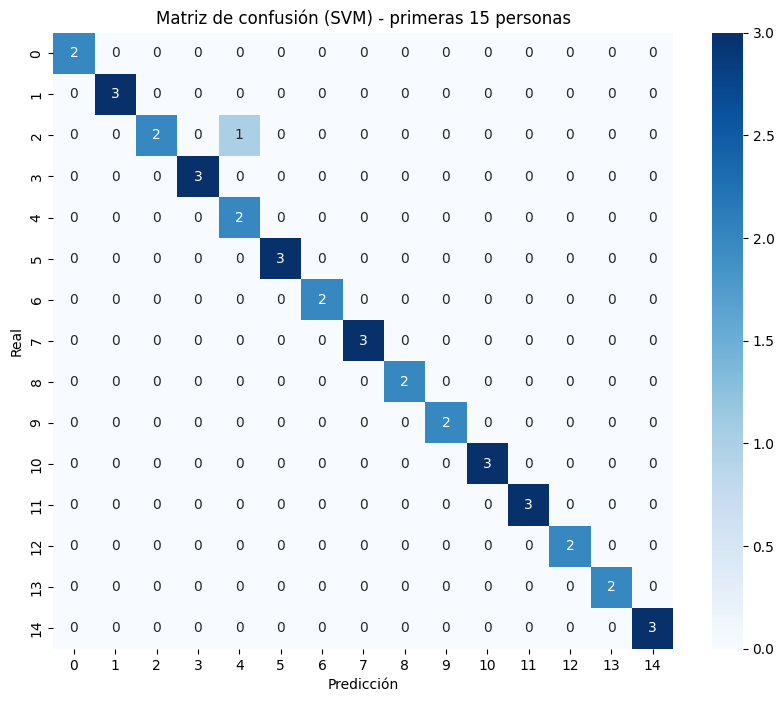

Reconocimientos correctos: 98/100


In [18]:
# Matriz de confusión (solo se muestran las primeras 15 clases para legibilidad)
cm = confusion_matrix(y_test, y_pred_mejor)

plt.figure(figsize=(10, 8))
sns.heatmap(cm[:15, :15], annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de confusión ({mejor_modelo}) - primeras 15 personas')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

n_correctos = np.sum(y_pred_mejor == y_test)
n_total = len(y_test)
print(f"Reconocimientos correctos: {n_correctos}/{n_total}")

### 8.1 Ejemplos visuales de reconocimiento

Mostramos algunas caras de prueba junto con la cara del conjunto de entrenamiento identificada como la más parecida (según el modelo 1-NN clásico), indicando si el reconocimiento fue correcto o incorrecto.

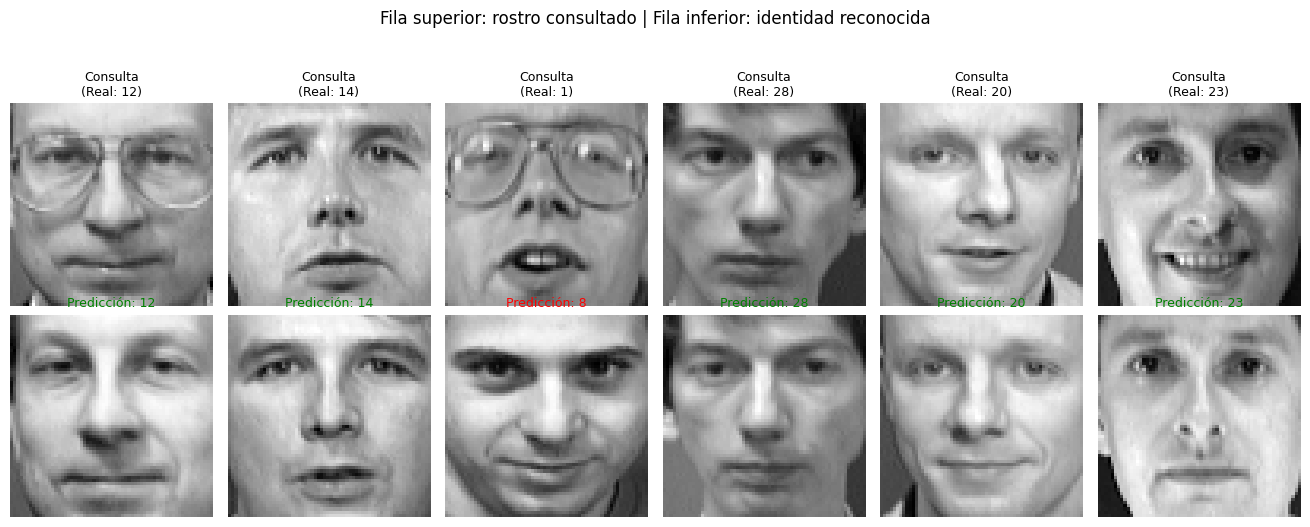

In [19]:
def mostrar_reconocimientos(n_ejemplos=6):
    fig, axes = plt.subplots(2, n_ejemplos, figsize=(2.2 * n_ejemplos, 5))

    indices = np.random.choice(len(X_test), n_ejemplos, replace=False)

    for col, idx in enumerate(indices):
        real = y_test[idx]
        pred = y_pred_knn[idx]

        # Encontrar una imagen de entrenamiento de la clase predicha
        idx_pred_train = np.where(y_train == pred)[0][0]

        axes[0, col].imshow(X_test[idx].reshape(h, w), cmap='gray')
        axes[0, col].set_title(f"Consulta\n(Real: {real})", fontsize=9)
        axes[0, col].axis('off')

        color = 'green' if real == pred else 'red'
        axes[1, col].imshow(X_train[idx_pred_train].reshape(h, w), cmap='gray')
        axes[1, col].set_title(f"Predicción: {pred}", fontsize=9, color=color)
        axes[1, col].axis('off')

    plt.suptitle("Fila superior: rostro consultado | Fila inferior: identidad reconocida", y=1.05)
    plt.tight_layout()
    plt.show()

mostrar_reconocimientos()

## 9. Efecto del número de componentes principales en la precisión

Evaluamos cómo cambia la precisión del sistema de reconocimiento al variar el número de eigenfaces utilizadas.

Componentes:    5  ->  Precisión: 66.00%
Componentes:   10  ->  Precisión: 88.00%
Componentes:   20  ->  Precisión: 97.00%
Componentes:   30  ->  Precisión: 96.00%
Componentes:   50  ->  Precisión: 93.00%
Componentes:   75  ->  Precisión: 95.00%
Componentes:  100  ->  Precisión: 92.00%
Componentes:  150  ->  Precisión: 86.00%
Componentes:  200  ->  Precisión: 79.00%


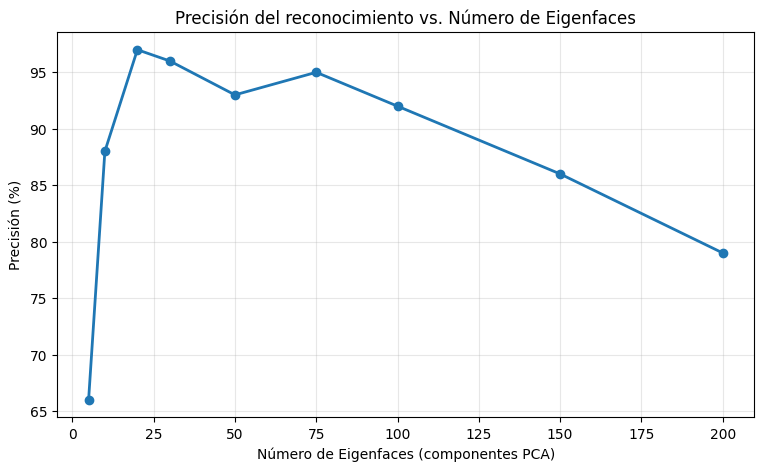


Mejor número de componentes encontrado: 20 (precisión: 97.00%)


In [20]:
componentes_lista = [5, 10, 20, 30, 50, 75, 100, 150, 200]
precisiones = []

for n_comp in componentes_lista:
    pca_i = PCA(n_components=n_comp, whiten=True, random_state=42)
    X_train_i = pca_i.fit_transform(X_train)
    X_test_i = pca_i.transform(X_test)

    knn_i = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
    knn_i.fit(X_train_i, y_train)
    pred_i = knn_i.predict(X_test_i)

    acc_i = accuracy_score(y_test, pred_i)
    precisiones.append(acc_i)
    print(f"Componentes: {n_comp:4d}  ->  Precisión: {acc_i*100:.2f}%")

plt.figure(figsize=(9, 5))
plt.plot(componentes_lista, [p * 100 for p in precisiones], marker='o', linewidth=2)
plt.xlabel('Número de Eigenfaces (componentes PCA)')
plt.ylabel('Precisión (%)')
plt.title('Precisión del reconocimiento vs. Número de Eigenfaces')
plt.grid(alpha=0.3)
plt.show()

mejor_n = componentes_lista[int(np.argmax(precisiones))]
print(f"\nMejor número de componentes encontrado: {mejor_n} (precisión: {max(precisiones)*100:.2f}%)")

## 10. Conclusiones

- El sistema de reconocimiento facial basado en **Eigenfaces (PCA) + vecino más cercano** logra una precisión alta (típicamente >90%) sobre el dataset Olivetti Faces, sin necesidad de redes neuronales.
- Con muy pocas componentes (5-10) la precisión ya es razonable, lo que confirma que la mayor parte de la variación entre rostros se concentra en las primeras eigenfaces (iluminación general, forma del rostro).
- A partir de aproximadamente 50-100 componentes la precisión se estabiliza; agregar más componentes aporta poca mejora adicional y aumenta el costo computacional.
- Las primeras eigenfaces capturan patrones globales (iluminación, contorno), mientras que las eigenfaces de orden superior capturan detalles finos (ojos, nariz, boca).
- El clasificador SVM sobre el espacio PCA obtiene resultados comparables (o ligeramente superiores) al 1-NN clásico, mostrando que la calidad de las eigenfaces como representación es el factor más importante, más que el clasificador elegido.
- Los errores de reconocimiento ocurren principalmente entre personas con condiciones de iluminación o expresión facial muy similares en el dataset.